# Sales Data Analysis Project

## Objective
The main objective of this project is to analyze sales data to identify:

- Sales trends
- Seasonal patterns
- High-performing stores
- Factors affecting sales

This project helps businesses make better decisions related to:
- Inventory management
- Sales forecasting
- Marketing strategies

# Importing Required Libraries

In this step, we import all the libraries required for data analysis and visualization.

### Libraries Used:
- Pandas → Data manipulation
- NumPy → Numerical operations
- Matplotlib → Data visualization
- Seaborn → Advanced visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the Dataset

Here we load the Walmart sales dataset into a DataFrame using Pandas.

A DataFrame is a table-like structure used for storing and analyzing data.

In [2]:
df = pd.read_csv("C:/Users/surek/OneDrive/Desktop/Walmart.csv")

# Display First 5 Rows

The `head()` function shows the first 5 rows of the dataset.

This helps us understand:
- Column names
- Data types
- Overall structure

In [3]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


# Dataset Information

The `info()` function provides:
- Number of rows and columns
- Column names
- Data types
- Missing values

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


# Statistical Summary

The `describe()` function gives statistical information such as:
- Mean
- Median
- Minimum value
- Maximum value
- Standard deviation

In [5]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


# Checking Missing Values

Missing values can affect analysis accuracy.

We use `isnull().sum()` to identify missing values in each column.

In [6]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

# Handling Missing Values

We remove missing values using `dropna()`.

This ensures clean and reliable data for analysis.

In [7]:
df.dropna(inplace=True)

# Checking Duplicate Rows

Duplicate rows can lead to incorrect analysis results.

We check duplicates using `duplicated().sum()`.

In [8]:
df.duplicated().sum()

np.int64(0)

# Removing Duplicate Rows

Duplicate records are removed to maintain data integrity.

In [9]:
df.drop_duplicates(inplace=True)

# Converting Date Column

The Date column is in `day-month-year` format.

We use:
- `pd.to_datetime()` → Converts object datatype into datetime datatype
- `dayfirst=True` → Ensures Pandas reads the first value as day

Example:
19-02-2010 → 19 February 2010

In [17]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [18]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


# Extracting Date Features

After converting the Date column, we extract:
- Year
- Month
- Day

These features help analyze sales trends over time.

In [20]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [21]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,12
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,19
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,26
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,5


# Total Sales Analysis

In this step, we calculate the total sales generated across all stores.

This helps us understand the overall business performance.

In [22]:
total_sales = df['Weekly_Sales'].sum()

print("Total Sales:", total_sales)

Total Sales: 6737218987.11


In [25]:
average_sales = df['Weekly_Sales'].mean()

print("Average Weekly Sales:", average_sales)

Average Weekly Sales: 1046964.8775617715


# Highest Weekly Sales

This analysis helps identify the maximum weekly sales achieved.

In [26]:
highest_sales = df['Weekly_Sales'].max()

print("Highest Weekly Sales:", highest_sales)

Highest Weekly Sales: 3818686.45


# Lowest Weekly Sales

This helps identify the minimum weekly sales value.

In [27]:
Lowest_sales = df['Weekly_Sales'].min()

print("Lowest Weekly Sales:", Lowest_sales)

Lowest Weekly Sales: 209986.25


# Sales Trend Over Time

A line chart is used to visualize how sales change over time.

This helps identify:
- Growth patterns
- Seasonal trends
- Sudden increases or decreases in sales

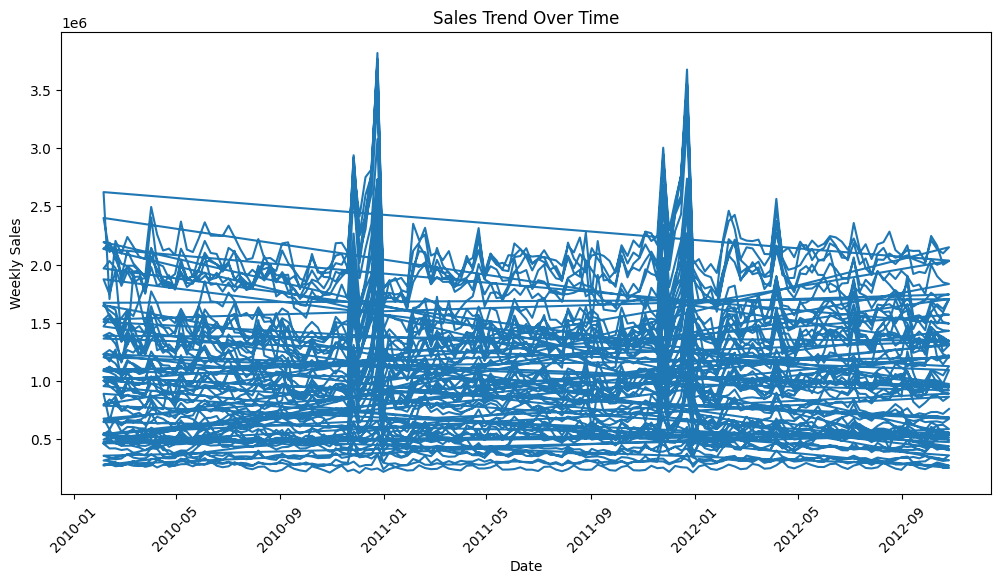

In [31]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Weekly_Sales'])

plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.xticks(rotation=45)

plt.show()

# Monthly Sales Analysis

In this step, we analyze total sales for each month.

This helps identify:
- Best-performing months
- Seasonal sales patterns
- Monthly business trends

In [34]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].sum()

print(monthly_sales)

Month
1     3.325984e+08
2     5.687279e+08
3     5.927859e+08
4     6.468598e+08
5     5.571256e+08
6     6.226299e+08
7     6.500010e+08
8     6.130902e+08
9     5.787612e+08
10    5.847848e+08
11    4.130157e+08
12    5.768386e+08
Name: Weekly_Sales, dtype: float64


# Monthly Sales Visualization

A bar chart is used to compare sales across different months.

This helps identify:
- High-sales months
- Low-sales months
- Seasonal demand

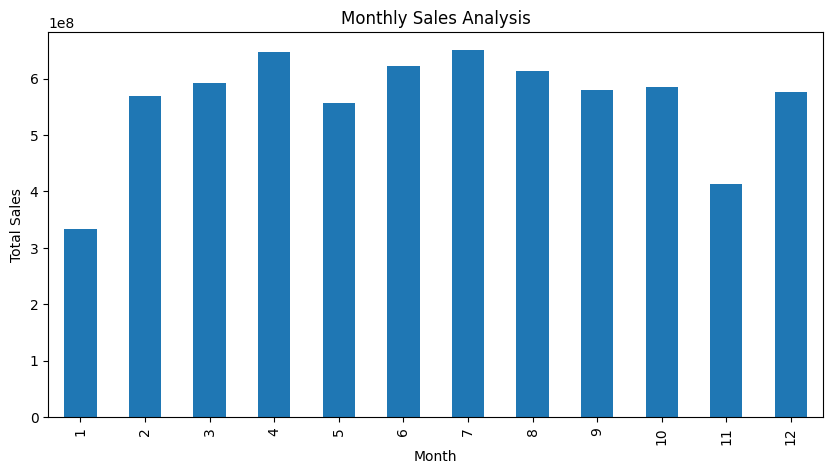

In [35]:
monthly_sales.plot(kind='bar', figsize=(10,5))

plt.title("Monthly Sales Analysis")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

# Top Performing Stores

This analysis identifies stores with the highest sales performance.

Businesses can use this information to:
- Improve low-performing stores
- Understand successful store strategies

In [37]:
top_stores = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

print(top_stores.head(10))

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
Name: Weekly_Sales, dtype: float64


# Top 10 Stores Visualization

A bar chart is used to compare the sales performance of top stores.

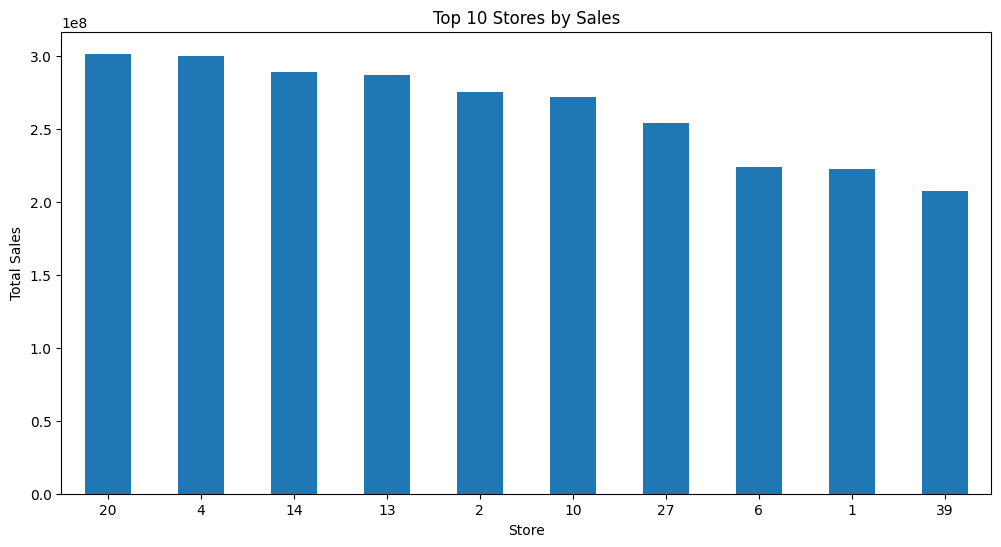

In [38]:
top_stores.head(10).plot(kind='bar', figsize=(12,6))

plt.title("Top 10 Stores by Sales")
plt.xlabel("Store")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)

plt.show()

# Holiday vs Non-Holiday Sales

In this step, we compare sales during:
- Holiday weeks
- Non-holiday weeks

This helps understand how holidays affect business revenue.

In [39]:
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

print(holiday_sales)

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64


# Holiday Sales Visualization

This bar chart compares average sales between holiday and non-holiday periods.

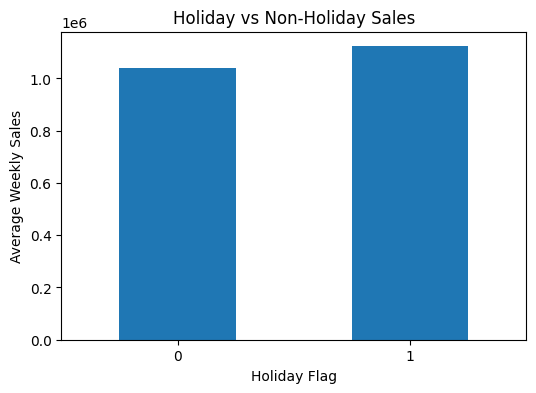

In [40]:
holiday_sales.plot(kind='bar', figsize=(6,4))

plt.title("Holiday vs Non-Holiday Sales")
plt.xlabel("Holiday Flag")
plt.ylabel("Average Weekly Sales")

plt.xticks(rotation=0)

plt.show()

# Temperature vs Weekly Sales

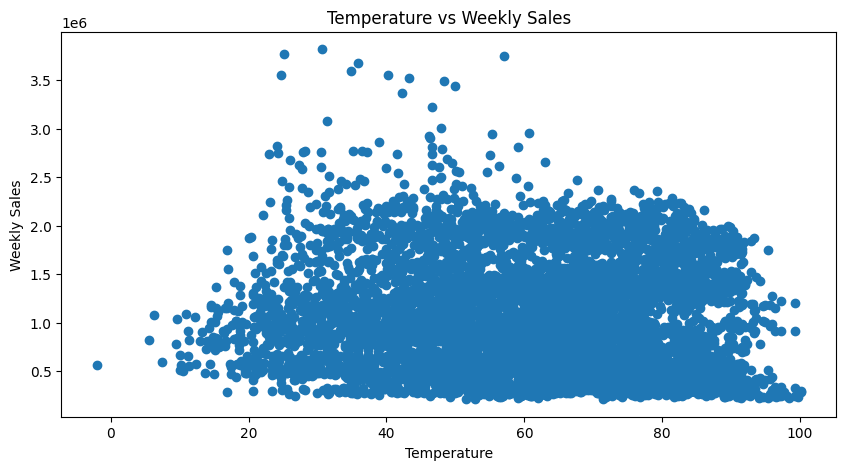

In [41]:
plt.figure(figsize=(10,5))

plt.scatter(df['Temperature'], df['Weekly_Sales'])

plt.title("Temperature vs Weekly Sales")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")

plt.show()

# Fuel Price vs Weekly Sales

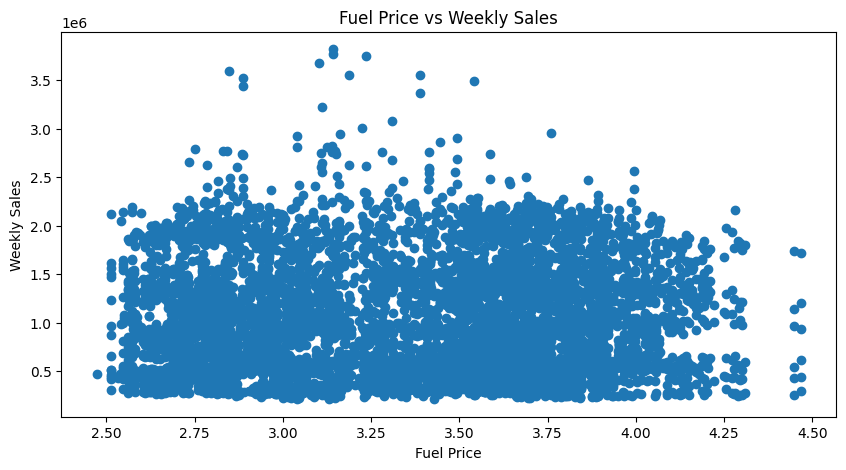

In [44]:
plt.figure(figsize=(10,5))

plt.scatter(df['Fuel_Price'], df['Weekly_Sales'])

plt.title("Fuel Price vs Weekly Sales")
plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")

plt.show()

# Correlation Heatmap

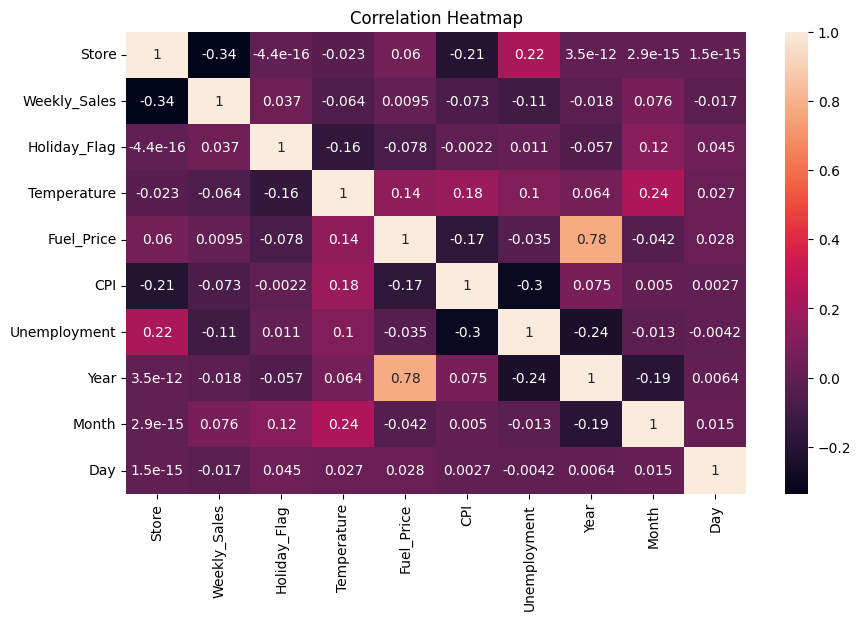

In [45]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Correlation Heatmap")

plt.show()

# Business Insights

## Observations

- Some stores generate higher sales than others.
- Holiday weeks usually increase sales.
- Seasonal patterns are visible in monthly sales.
- External factors slightly affect sales.

# Conclusion

In this project, we performed:

- Data Cleaning
- Data Analysis
- Data Visualization
- Sales Trend Analysis

The project successfully identified important business insights using Python.